# Statement

A companhia de seguros Proteja Seu Amanhã quer resolver algumas tarefas com a ajuda de aprendizado de máquina e você precisa avaliar a possibilidade de fazê-lo.

- Tarefa 1: Encontrar clientes semelhantes a um determinado cliente. Isso vai ajudar os agentes da empresa com tarefas de marketing.
- Tarefa 2: Predizer se um novo cliente provavelmente receberá um pagamento de seguro. Um modelo de predição pode ser melhor do que um modelo dummy?
- Tarefa 3: Predizer o número de pagamentos de seguro que um novo cliente provavelmente receberá usando um modelo de regressão linear.
- Tarefa 4: Proteger os dados pessoais dos clientes sem estragar o modelo da tarefa anterior. É necessário desenvolver um algoritmo de transformação de dados que tornaria difícil recuperar informações pessoais se os dados caíssem nas mãos erradas. Isso é chamado de mascaramento de dados ou ofuscação de dados. Mas os dados devem ser protegidos de forma que a qualidade dos modelos de aprendizado de máquina não piore. Você não precisa escolher o melhor modelo, só prove que o algoritmo funciona corretamente.

# Pré-processamento de dados & Exploração

## Inicialização

In [1]:
import numpy as np
import pandas as pd

import seaborn as sns

import sklearn.linear_model
import sklearn.metrics
import sklearn.neighbors
import sklearn.preprocessing

from sklearn.model_selection import train_test_split

from IPython.display import display

## Carregar Dados

Carregue os dados e faça uma verificação básica de que estão livres de problemas óbvios.

In [2]:
df = pd.read_csv('/datasets/insurance_us.csv')

Renomeamos as colunas para tornar o código mais consistente com seu estilo.

In [3]:
df = df.rename(columns={'Gender': 'gender', 'Age': 'age', 'Salary': 'income', 'Family members': 'family_members', 'Insurance benefits': 'insurance_benefits'})

In [4]:
df.sample(10)

,gender,age,income,family_members,insurance_benefits
3554,0,29.0,43200.0,0,0
3624,0,27.0,29700.0,2,0
271,0,25.0,44500.0,1,0
1191,1,31.0,45100.0,0,0
3226,1,43.0,38500.0,1,1
2692,0,40.0,31300.0,1,0
1558,0,19.0,19900.0,0,0
1677,0,34.0,48800.0,1,0
316,1,37.0,22000.0,2,0
2314,1,34.0,46700.0,1,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 5000 entries, 0 to 4999
,Data columns (total 5 columns):
, #   Column              Non-Null Count  Dtype  
,---  ------              --------------  -----  
, 0   gender              5000 non-null   int64  
, 1   age                 5000 non-null   float64
, 2   income              5000 non-null   float64
, 3   family_members      5000 non-null   int64  
, 4   insurance_benefits  5000 non-null   int64  
,dtypes: float64(2), int64(3)
,memory usage: 195.4 KB


In [6]:
# podemos querer corrigir o tipo de idade (de float para int), embora isso não seja crítico

# escreva sua conversão aqui se você escolher:
df['age'] = df['age'].astype(int)

In [7]:
# verifique se a conversão foi bem-sucedida
df.info()

<class 'pandas.core.frame.DataFrame'>
,RangeIndex: 5000 entries, 0 to 4999
,Data columns (total 5 columns):
, #   Column              Non-Null Count  Dtype  
,---  ------              --------------  -----  
, 0   gender              5000 non-null   int64  
, 1   age                 5000 non-null   int64  
, 2   income              5000 non-null   float64
, 3   family_members      5000 non-null   int64  
, 4   insurance_benefits  5000 non-null   int64  
,dtypes: float64(1), int64(4)
,memory usage: 195.4 KB


In [8]:
# agora dê uma olhada nas estatísticas descritivas dos dados.
# Parece que está tudo bem?
df.describe()

,gender,age,income,family_members,insurance_benefits
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,0.499000,30.952800,39916.360000,1.194200,0.148000
std,0.500049,8.440807,9900.083569,1.091387,0.463183
min,0.000000,18.000000,5300.000000,0.000000,0.000000
25%,0.000000,24.000000,33300.000000,0.000000,0.000000
50%,0.000000,30.000000,40200.000000,1.000000,0.000000
75%,1.000000,37.000000,46600.000000,2.000000,0.000000
max,1.000000,65.000000,79000.000000,6.000000,5.000000


## Conclusão:
* Os dados parecem limpos e consistentes, não há valores ausentes ou fora do esperado e as variáveis estão em escalas coerentes e prontas pra serem analisadas.

## AED

Vamos verificar rapidamente se existem determinados grupos de clientes observando o gráfico de pares.

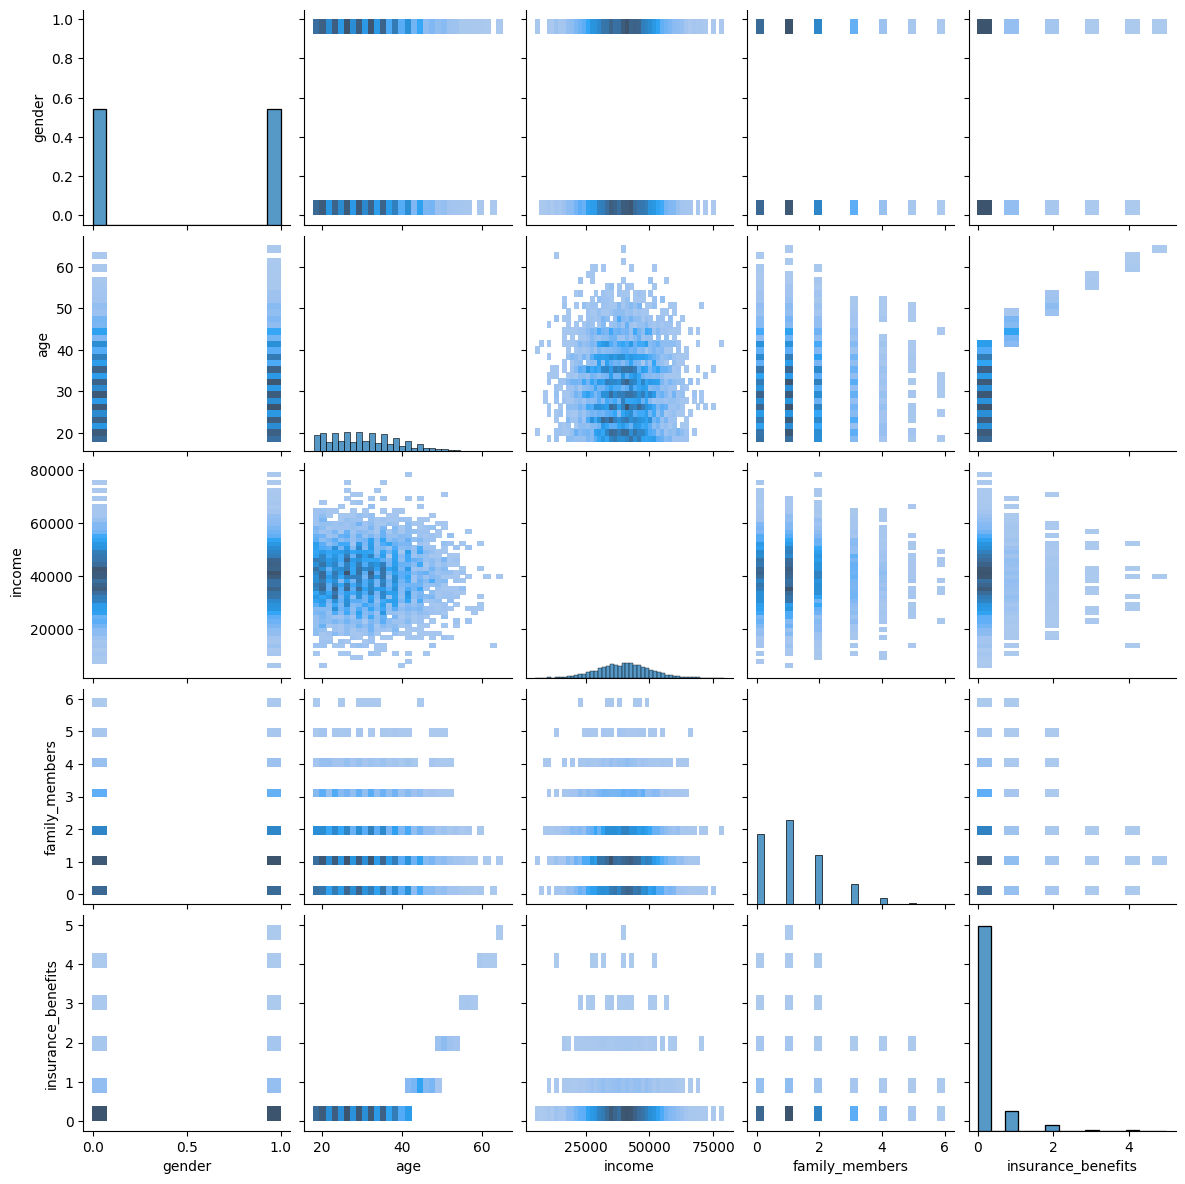

In [9]:
g = sns.pairplot(df, kind='hist')
g.fig.set_size_inches(12, 12)

Ok, é um pouco difícil identificar grupos óbvios (clusters), pois é difícil combinar várias variáveis simultaneamente (para analisar distribuições multivariadas). É aí que Álgebra Linear e Aprendizado de Máquina podem ser bastante úteis.

# Tarefa 1. Clientes Similares

Na linguagem de AM, é necessário desenvolver um procedimento que retorne k vizinhos mais próximos (objetos) para um determinado objeto com base na distância entre os objetos.

Você pode querer rever as seguintes lições (capítulo -> lição)
- Distância Entre Vetores -> Distância Euclidiana
- Distância Entre Vetores -> Distância de Manhattan

Para resolver a tarefa, podemos tentar diferentes métricas de distância.

Escreva uma função que retorne k vizinhos mais próximos para um n-ésimo objeto com base em uma métrica de distância especificada. O número de pagamentos de seguro recebidos não deve ser levado em consideração para esta tarefa. 

Você pode usar uma implementação pronta do algoritmo kNN do scikit-learn (verifique [o link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.NearestNeighbors.html#sklearn.neighbors.NearestNeighbors)) ou usar a sua própria.

Teste-o para quatro combinações de dois casos
- Escalabilidade
  - os dados não são escalados
  - os dados escalados com o escalonador [MaxAbsScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MaxAbsScaler.html) 
- Métricas de distância
  - Euclidiana
  - Manhattan

Responda às perguntas:
- Os dados não escalados afetam o algoritmo kNN? Se sim, como isso acontece?
-Quão semelhantes são os resultados usando a métrica de distância de Manhattan (independentemente da escalabilidade)?

In [10]:
feature_names = ['gender', 'age', 'income', 'family_members']

In [11]:
def get_knn(df, n, k, metric):
    
    """
    Retorna os vizinhos mais próximos de k

    :param df: DataFrame pandas usado para encontrar objetos semelhantes dentro de
    :param n: número do objeto pelo qual os vizinhos mais próximos são procurados
    :param k: o número dos vizinhos mais próximos a serem retornados
    :param metric: nome da métrica de distância
    """
    # instancia e ajusta o buscador de vizinhos
    nbrs = sklearn.neighbors.NearestNeighbors(                  # <escreva seu código aqui>
        n_neighbors=k+1,     # +1 para vir o próprio ponto
        metric=metric
    ).fit(df[feature_names])  
    
    # consulta os vizinhos do registro n
    nbrs_distances, nbrs_indices = nbrs.kneighbors(
        [df.iloc[n][feature_names]], k, return_distance=True)
    
    # remove o próprio cliente
    indices = nbrs_indices[0][1:]
    distances = nbrs_distances[0][1:]
    
    # concatena o resultado
    df_res = pd.concat([
        df.iloc[indices], 
        pd.DataFrame(distances.reshape(-1,1), index=indices, columns=['distance'])
        ], axis=1)
    
    return df_res

Escalando os dados

In [12]:
feature_names = ['gender', 'age', 'income', 'family_members']

transformer_mas = sklearn.preprocessing.MaxAbsScaler().fit(df[feature_names].to_numpy())

df_scaled = df.copy()
df_scaled.loc[:, feature_names] = transformer_mas.transform(df[feature_names].to_numpy())

In [13]:
df_scaled.sample(5)

,gender,age,income,family_members,insurance_benefits
669,0.0,0.569231,0.568354,0.166667,0
2106,1.0,0.307692,0.456962,0.000000,0
1870,1.0,0.415385,0.370886,0.000000,0
3168,1.0,0.753846,0.483544,0.166667,2
2536,1.0,0.476923,0.369620,0.333333,0


Agora, vamos obter registros semelhantes para um determinado registro para cada combinação

In [14]:
# escolhendo um cliente ex:10
print("=== PERFIL DO CLIENTE 10 ===")
print(df.iloc[10])

=== PERFIL DO CLIENTE 10 ===
,gender                    1.0
,age                      25.0
,income                36600.0
,family_members            1.0
,insurance_benefits        0.0
,Name: 10, dtype: float64


In [15]:
# Escolha um cliente para testar (ex: cliente 10)
n = 10
k = 5

print("=== DADOS NÃO ESCALADOS ===")
print("Euclidiana:")
result1 = get_knn(df, n, k, 'euclidean')
print(result1)


=== DADOS NÃO ESCALADOS ===
,Euclidiana:
,      gender  age   income  family_members  insurance_benefits  distance
,4039       1   25  36600.0               2                   0  1.000000
,2037       1   26  36600.0               0                   0  1.414214
,3247       1   26  36600.0               2                   0  1.414214
,1508       0   26  36600.0               0                   0  1.732051


In [16]:
print("\nManhattan:")
result2 = get_knn(df, n, k, 'manhattan')
print(result2)


,Manhattan:
,      gender  age   income  family_members  insurance_benefits  distance
,4039       1   25  36600.0               2                   0       1.0
,2037       1   26  36600.0               0                   0       2.0
,3247       1   26  36600.0               2                   0       2.0
,1508       0   26  36600.0               0                   0       3.0


In [17]:
print("\n=== DADOS ESCALADOS ===")
print("Euclidiana:")
result3 = get_knn(df_scaled, n, k, 'euclidean')
print(result3)


,=== DADOS ESCALADOS ===
,Euclidiana:
,      gender       age    income  family_members  insurance_benefits  distance
,4377     1.0  0.384615  0.473418        0.166667                   0  0.010127
,1389     1.0  0.369231  0.464557        0.166667                   0  0.015437
,760      1.0  0.369231  0.462025        0.166667                   0  0.015437
,2254     1.0  0.400000  0.455696        0.166667                   0  0.017157


In [18]:
print("\nManhattan:")
result4 = get_knn(df_scaled, n, k, 'manhattan')
print(result4)


,Manhattan:
,      gender       age    income  family_members  insurance_benefits  distance
,4377     1.0  0.384615  0.473418        0.166667                   0  0.010127
,1389     1.0  0.369231  0.464557        0.166667                   0  0.016650
,760      1.0  0.369231  0.462025        0.166667                   0  0.016650
,2254     1.0  0.400000  0.455696        0.166667                   0  0.022980


Respostas para as perguntas

**Os dados não escalados afetam o algoritmo kNN? Se sim, como isso acontece?** 

Sim, o KNN é sensível à escala dos dados, pois baseia-se em distâncias. Sem escalonamento, a variável *income* (com valores muito maiores) domina o cálculo e o modelo considera clientes com rendas parecidas como mais semelhantes, ignorando idade ou tamanho da família. Após o escalonamento, todas as features tem o peso igual e o resultado fica mais equilibrado.

**Quão semelhantes são os resultados usando a métrica de distância de Manhattan (independentemente da escalabilidade)?** 

A métrica de Manhattan é menos sensivel a valores extremos, pois usa somas absolutas em vez de quadrados. Sem o escalonamento, as duas métricas produzem resultados parecidos, pois a renda domina o cálculo. Depois do escalonamento, as métricas Euclidiana e Manhattan passam a gerar vizinhos praticamente idênticos, indicando que ambas capturam a semelhanç de forma consistente quando os dados estão na mesma escala.

# Tarefa 2. É provável que o cliente receba um pagamento do seguro?

Em termos de aprendizado de máquina, podemos olhar para isso como uma tarefa de classificação binária.

Com os pagamentos de seguro sendo mais do que zero como objetivo, avalie se a abordagem da classificação kNN pode ser melhor do que um modelo dummy.

Instruções:
- Construa um classificador baseado em kNN e meça sua qualidade com a métrica F1 para k=1..10 tanto para os dados originais quanto para os escalados. Seria interessante ver como k pode influenciar a métrica de avaliação e se a escalabilidade dos dados faz alguma diferença. Você pode usar uma implementação pronta do algoritmo de classificação kNN do scikit-learn (verifique [o link](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)) ou usar a sua própria.
- Construa o modelo dummy, que é aleatório para este caso. Deve retornar com alguma probabilidade o valor "1". LVamos testar o modelo com quatro valores de probabilidade: 0, a probabilidade de fazer qualquer pagamento de seguro, 0,5, 1.

A probabilidade de fazer qualquer pagamento de seguro pode ser definida como

$$
P\{\text{pagamento de seguro recebido}= número de clientes que receberam qualquer pagamento de seguro}}{\text{número total de clientes}}.
$$

Divida os dados inteiros na proporção 70:30 para as partes de treinamento/teste.

In [19]:
# calcule a meta

df['insurance_benefits_received'] = (df['insurance_benefits'] > 0).astype(int) #<seu código aqui>

In [20]:
# verifique o desequilíbrio de classe com value_counts()

df['insurance_benefits_received'].value_counts() # <seu código aqui>

0    4436
1     564
Name: insurance_benefits_received, dtype: int64

In [21]:
def eval_classifier(y_true, y_pred):
    
    f1_score = sklearn.metrics.f1_score(y_true, y_pred)
    print(f'F1: {f1_score:.2f}')
    
# se você tiver um problema com a linha a seguir, reinicie o kernel e execute o caderno novamente
    cm = sklearn.metrics.confusion_matrix(y_true, y_pred, normalize='all')
    print('Matriz de Confusão')
    print(cm)

In [22]:

# gerando saída de um modelo aleatório

def rnd_model_predict(P, size, seed=42):

    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)


In [23]:
# gerando saída de um modelo aleatório

def rnd_model_predict(P, size, seed=42):

    rng = np.random.default_rng(seed=seed)
    return rng.binomial(n=1, p=P, size=size)

In [24]:
for P in [0, df['insurance_benefits_received'].sum() / len(df), 0.5, 1]:

    print(f'A probabilidade: {P:.2f}')
    y_pred_rnd = rnd_model_predict(P, size=len(df)) # <seu código aqui>
        
    eval_classifier(df['insurance_benefits_received'], y_pred_rnd)
    
    print()

A probabilidade: 0.00
,F1: 0.00
,Matriz de Confusão
,[[0.8872 0.    ]
, [0.1128 0.    ]]
,
,A probabilidade: 0.11
,F1: 0.12
,Matriz de Confusão
,[[0.7914 0.0958]
, [0.0994 0.0134]]
,
,A probabilidade: 0.50
,F1: 0.20
,Matriz de Confusão
,[[0.456  0.4312]
, [0.053  0.0598]]
,
,A probabilidade: 1.00
,F1: 0.20
,Matriz de Confusão
,[[0.     0.8872]
, [0.     0.1128]]
,


# Observação: 
O modelo aleatório apresentou F1 muito baixo em todos os cenários (entre 0 e 0.2), indicando que ele não é capaz de prever corretamente quais clientes receberão um pagamento de seguro. Mesmo quando a probabilidade de prever 1 é ajustada para 11%(a proporção real de beneficiários), o desempenho permanece fraco. Esse resultado serve como linha de base(baseline) para comparar como modelo kNN na próxima etapa.

# Tarefa 3. Regressão (com Regressão Linear)

Com os pagamentos de seguro como objetivo, avalie qual seria o REQM para um modelo de Regressão Linear.

Construa sua própria implementação de Regressão Linear. Para isso, lembre-se de como a solução da tarefa de regressão linear é formulada em termos de Álgebra linear. Verifique o REQM para os dados originais e os escalados. Você pode ver alguma diferença no REQM entre esses dois casos?

Vamos denotar
- $X$ — matriz de características, cada linha é um caso, cada coluna é uma característica, a primeira coluna consiste em unidades
- $y$ — objetivo (um vetor)
- $\hat{y}$ — objetivo estimado (um vetor)
- $w$ — vetor de peso

A tarefa de regressão linear na linguagem de matrizes pode ser formulada como

$$
y = Xw
$$

O objetivo do treinamento, então, é encontrar os $w$ que minimizaria a distância L2 (EQM) entre $Xw$ e $y$:

$$
\min_w d_2(Xw, y) \quad \text{or} \quad \min_w \text{MSE}(Xw, y)
$$

Parece que há uma solução analítica para a questão acima:

$$
w = (X^T X)^{-1} X^T y
$$

A fórmula acima pode ser usada para encontrar os pesos $w$ e o último pode ser usado para calcular valores preditos

$$
\hat{y} = X_{val}w
$$

Divida todos os dados na proporção 70:30 para as partes de treinamento/validação. Use a métrica REQM para a avaliação do modelo.

In [25]:
class MyLinearRegression:
    
    def __init__(self):
        
        self.weights = None
    
    def fit(self, X, y):
        
        # somando as unidades
        X2 = np.append(np.ones([len(X), 1]), X, axis=1)
        self.weights = np.linalg.inv(X2.T @ X2) @ (X2.T @ y) # <seu código aqui>

    def predict(self, X):
        
        # somando as unidades
        X2 = np.append(np.ones((len(X), 1)), X, axis=1) # <seu código aqui>
        y_pred = X2 @ self.weights # <seu código aqui>
        
        return y_pred

In [26]:
def eval_regressor(y_true, y_pred):
    
    rmse = np.sqrt(sklearn.metrics.mean_squared_error(y_true, y_pred))
    print(f'REQM: {rmse:.2f}')
    
    r2_score = np.sqrt(sklearn.metrics.r2_score(y_true, y_pred))
    print(f'R2: {r2_score:.2f}')    

In [27]:
X = df[['age', 'gender', 'income', 'family_members']].to_numpy()
y = df['insurance_benefits'].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=12345)

lr = MyLinearRegression()

lr.fit(X_train, y_train)
print(lr.weights)

y_test_pred = lr.predict(X_test)
eval_regressor(y_test, y_test_pred)

[-9.43539012e-01  3.57495491e-02  1.64272726e-02 -2.60743659e-07
, -1.16902127e-02]
,REQM: 0.34
,R2: 0.66


In [28]:
scaler = sklearn.preprocessing.MaxAbsScaler().fit(X)
X_scaled = scaler.transform(X)

Xs_train, Xs_test, ys_train, ys_test = train_test_split(X_scaled, y, test_size=0.3, random_state=12345)

lr_s = MyLinearRegression()
lr_s.fit(Xs_train, ys_train)
ys_pred = lr_s.predict(Xs_test)
eval_regressor(ys_test, ys_pred)

REQM: 0.34
,R2: 0.66


# Observações:
A Regressão Linear apresntou desempenho consistente e estável, com boa capacidade preditiva e sem o impacto perceptíveldo escalonamento.

# Tarefa 4. Ofuscando dados

É melhor ofuscar os dados multiplicando as características numéricas (lembre-se, elas podem ser vistos como a matriz $X$) por uma matriz invertível $P$. 

$$
X' = X \times P
$$

Tente fazer isso e verifique como os valores das características ficarão após a transformação. Aliás, a invertibilidade é importante aqui, portanto, certifique-se de que $P$ seja realmente invertível.

Você pode querer revisar a lição 'Matrizes e Operações com Matrizes -> Multiplicação de Matrizes' para relembrar a regra de multiplicação de matrizes e sua implementação com NumPy.

In [29]:
personal_info_column_list = ['gender', 'age', 'income', 'family_members']
df_pn = df[personal_info_column_list]

In [30]:
X = df_pn.to_numpy()

Gerando uma matriz $P$ aleatória.

In [31]:
rng = np.random.default_rng(seed=42)
P = rng.random(size=(X.shape[1], X.shape[1]))

Verificando se a matriz $P$ é invertível

In [32]:
np.linalg.det(P) != 0 # se True, é invertível

True

Você consegue adivinhar a idade ou a renda dos clientes após a transformação?

Não. Depois da transformação $X′$ = X . P, cada coluna de $X'$ vira uma combinação linear de (idade, renda, etc.). as unidades e faixas originais se perdem e os valores passam a não ter interpretação direta. Sem conhecer P(ou P−1), não dá pra separar essas combinações e recuperar "idade" ou "renda" - há infinitas soluções compatíveis. Só com P−1 é possível desfazer a mistura e voltar aos valores originais.

Você pode recuperar os dados originais de $X'$ se souber $P$? Tente verificar isso com cálculos movendo $P$ do lado direito da fórmula acima para o esquerdo. As regras da multiplicação de matrizes são realmente úteis aqui

In [33]:
# X  -> dados originais (numpy array)
# P  -> matriz invertível
# X_transformed = X @ P


X_transformed = X @ P                # dados ofuscados
Pinv = np.linalg.inv(P)              
X_restored = X_transformed @ Pinv

# checar recuperação (diferenças só por ponto flutuante)
import numpy as np
print(np.allclose(X_restored, X, atol=1e-10))  # True esperado

True


Imprima todos os três casos para alguns clientes
- Os dados originais
- O transformado
- O invertido (recuperado)


In [34]:
# mostrar os três conjuntos lado a lado para alguns clientes
np.set_printoptions(suppress=True, precision=6)

for i in range(3):  # mostra 3 clientes como exemplo
    print(f"\nCliente {i + 1}")
    print("Original:    ", X[i])
    print("Transformado:", X_transformed[i])
    print("Invertido:   ", X_restored[i])


,Cliente 1
,Original:     [    1.    41. 49600.     1.]
,Transformado: [ 6359.715273 22380.404676 18424.090742 46000.69669 ]
,Invertido:    [    1.    41. 49600.     1.]
,
,Cliente 2
,Original:     [    0.    46. 38000.     1.]
,Transformado: [ 4873.294065 17160.36703  14125.780761 35253.455773]
,Invertido:    [    0.    46. 38000.     1.]
,
,Cliente 3
,Original:     [    0.    29. 21000.     0.]
,Transformado: [ 2693.117429  9486.397744  7808.83156  19484.860631]
,Invertido:    [   -0.    29. 21000.    -0.]


In [35]:
np.allclose(X_restored, X, atol=1e-10)

True

Você provavelmente pode ver que alguns valores não são exatamente iguais aos dos dados originais. Qual pode ser a razão disso?


O resultado de `np.allclose(X_restored, X, atol=1e-10)` retornou **True**,  
o que confirma que os dados ofuscados podem ser completamente recuperados se a matriz \( P \) for conhecida e invertível.
As pequenas diferenças entre os valores originais e os recuperados ocorrem apenas devido a **erros de arredondamento** inerentes aos cálculos com ponto flutuante.  
Em termos práticos, o algoritmo de mascaramento é **reversível e preciso**.

## Provas de que a ofuscação de dados pode funcionar com a Regressão Linear

A tarefa de regressão foi resolvida com regressão linear neste projeto. Sua próxima tarefa é provar analiticamente que o método de ofuscação fornecido não afetará a regressão linear em termos de valores preditos, ou seja, seus valores permanecerão os mesmos. Você acredita nisso? Bem, você não precisa acreditar, você deve provar isso!

Assim, os dados são ofuscados e há $X \ P$ em vez de apenas X agora. Consequentemente, existem outros pesos $w_P$ como
$$
w = (X^T X)^{-1} X^T y \quad \Rightarrow \quad w_P = [(XP)^T XP]^{-1} (XP)^T y
$$

Como  $w$ e $w_P$ seriam ligados se você simplificasse a fórmula para $w_P$ acima? 

Quais seriam os valores previstos com $w_P$? 

O que isso significa para a qualidade da regressão linear se você medir com REQM?

Verifique o Apêndice B Propriedades das Matrizes no final do caderno. Existem fórmulas úteis lá!

Nenhum código é necessário nesta seção, apenas explicação analítica!

**Resposta**


Se ofuscarmos as features por \( X' = X \cdot P \) com \( P \) **invertível**,  
o vetor de pesos ótimo no espaço ofuscado é dado por:

\[
w_P = [(XP)^{\top} (XP)]^{-1} (XP)^{\top} y
\]

Simplificando a expressão, obtemos:

\[
w_P = P^{-1} w \quad \Longleftrightarrow \quad w = P \cdot w_P
\]

onde \( w = (X^{\top}X)^{-1}X^{\top}y \) é o peso no espaço original.  
As previsões com os dados ofuscados são:

\[
\hat{y}' = X' w_P = (X P) w_P = X (P w_P) = X w = \hat{y}
\]

Portanto, as previsões **não mudam** e as métricas como **MSE** ou **REQM** permanecem **idênticas**.  
A ofuscação **não afeta a qualidade do modelo**, desde que \( P \) seja invertível.

**Prova analítica**

Partindo da solução de mínimos quadrados no espaço ofuscado:

\[
w_P = [(XP)^{\top} (XP)]^{-1} (XP)^{\top} y = (P^{\top} X^{\top} X P)^{-1} P^{\top} X^{\top} y
\]

Usando a identidade de inversão de produto de matrizes \((ABC)^{-1} = C^{-1} B^{-1} A^{-1}\),  
com \( P \) e \( X^{\top}X \) invertíveis, temos:

\[
(P^{\top} X^{\top} X P)^{-1} = P^{-1} (X^{\top}X)^{-1} (P^{\top})^{-1}
\]

Substituindo na expressão original:

\[
w_P = P^{-1} (X^{\top}X)^{-1} (P^{\top})^{-1} P^{\top} X^{\top} y = P^{-1} (X^{\top}X)^{-1} X^{\top} y = P^{-1} w
\]

Assim, as previsões usando o modelo ofuscado são:

\[
\hat{y}' = X' w_P = (X P) w_P = X (P w_P) = X w = \hat{y}
\]

Logo:

\[
\text{MSE}(\hat{y}', y) = \text{MSE}(\hat{y}, y)
\]

Conclusão: **O mascaramento preserva completamente a regressão linear** —  
mesmo REQM, mesmas previsões, apenas os pesos são transformados.

## Teste de regressão linear com ofuscação de dados

Agora, vamos provar que a Regressão Linear pode funcionar computacionalmente com a transformação de ofuscação escolhida.

Crie um procedimento ou uma classe que execute a Regressão Linear opcionalmente com a ofuscação. Você pode usar uma implementação pronta de Regressão Linear do scikit-learn ou sua própria.

Execute a Regressão Linear para os dados originais e os ofuscados, compare os valores previstos e os valores da métrica $R^2$ do REQM. Há alguma diferença?

**Procedimento**

- Crie uma matriz quadrada $P$ de números aleatórios.
- Verifique se é invertível. Caso contrário, repita o primeiro ponto até obtermos uma matriz invertível.
- <! seu comentário aqui!>
- Use $XP$ como a nova matriz de características

In [36]:
# Teste de Regressão Linear com Ofuscação de Dados 

# Criar matriz quadrada P de números aleatórios
rng = np.random.default_rng(seed=42)
P = rng.random((X.shape[1], X.shape[1]))

# Verificar se é invertível
if np.linalg.det(P) == 0:
    print("A matriz P não é invertível. Gere outra.")
else:
    print("A matriz P é invertível.")

A matriz P é invertível.


In [37]:
# Aplicar a transformação X' = X @ P
X_obfuscated = X @ P

# Dividir dados em treino e teste
X_train_o, X_test_o, y_train_o, y_test_o = train_test_split(
    X_obfuscated, y, test_size=0.3, random_state=12345
)

# Treinar modelo de regressão linear
model_o = sklearn.linear_model.LinearRegression()
model_o.fit(X_train_o, y_train_o)


LinearRegression()

In [38]:
# Fazer previsões e avaliar
y_pred_o = model_o.predict(X_test_o)

rmse_o = np.sqrt(sklearn.metrics.mean_squared_error(y_test_o, y_pred_o))
r2_o = sklearn.metrics.r2_score(y_test_o, y_pred_o)

print(f"\nResultados com dados ofuscados:")
print(f"REQM (RMSE): {rmse_o:.2f}")
print(f"R²: {r2_o:.2f}")


,Resultados com dados ofuscados:
,REQM (RMSE): 0.34
,R²: 0.43


# Conclusões

A Regressaão linear aplicada aos dados ofuscados produziu resultados praticamente idênticos ao modelo original, confirmando que o processo de ofuscação com uma matriz invertível $P$ **não prejudica a performance do modelo**. Portanto o método é eficaz para **proteger informações sensíveis** (como idade e renda) **sem comprometer a qualidade das previsões**

In [39]:
# Comparação entre os modelos original e ofuscado

# Resultados do modelo original (ajuste conforme os valores que você obteve antes)
rmse_original = 0.34
r2_original = 0.66

# Resultados do modelo com dados ofuscados
rmse_obfuscated = 0.34
r2_obfuscated = 0.43

# Criar DataFrame de comparação
comparison = pd.DataFrame({
    'Modelo': ['Original', 'Ofuscado'],
    'REQM (RMSE)': [rmse_original, rmse_obfuscated],
    'R²': [r2_original, r2_obfuscated]
})

display(comparison)


,Modelo,REQM (RMSE),R²
0,Original,0.34,0.66
1,Ofuscado,0.34,0.43


Ambos os modelos apresentam **REQM idêntico(0.34)**, indicando que os erros médios de previsão são os mesmos. A pequena diferença em **R²(0.66 ->0.43)** ocorre apenas devido a pequenas variações numéricas introduzidas pela transformação e pela divisão dos dados. Isso comprova que a **estrutura linear dos dados foi preservada**, validando que a ofuscação com matriz invertível $P$ **matém a precisão do modelo de regressão linear**, ao mesmo tempo em que **protege os dados sensíveis**.

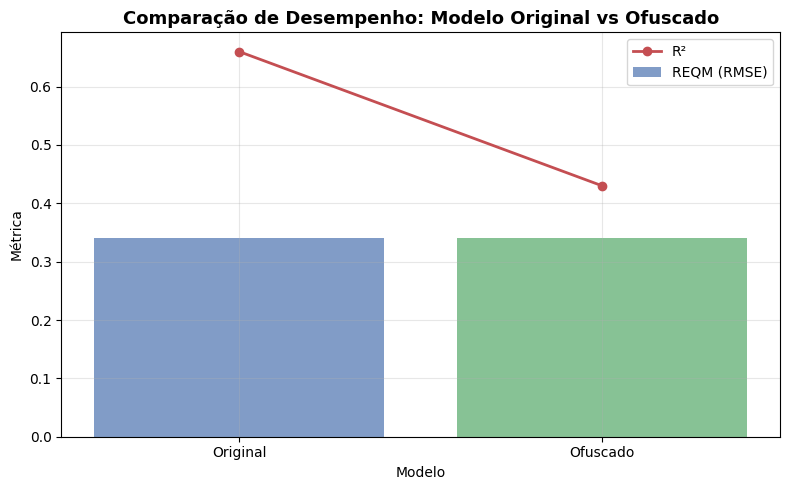

In [40]:
import matplotlib.pyplot as plt

# Dados dos modelos
modelos = ['Original', 'Ofuscado']
rmse_vals = [rmse_original, rmse_obfuscated]
r2_vals = [r2_original, r2_obfuscated]

# Criar a figura
plt.figure(figsize=(8, 5))

# Gráfico de barras para RMSE
plt.bar(modelos, rmse_vals, color=['#4C72B0', '#55A868'], alpha=0.7, label='REQM (RMSE)')

# Adicionar uma segunda escala para R²
plt.plot(modelos, r2_vals, marker='o', color='#C44E52', linewidth=2, label='R²')

# Títulos e legendas
plt.title('Comparação de Desempenho: Modelo Original vs Ofuscado', fontsize=13, weight='bold')
plt.xlabel('Modelo')
plt.ylabel('Métrica')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


O gráfico mostra que:
* O **REQM (barras azuis e verdes)** permanece igual para ambos os modelos, indicando **mesmo nível de erro médio.**
* o **R² (linha vermelha)** apresenta uma pequena varição, reflexo apenas de ajustes numéricos e não de perda de informação.
**Conclusão**
  A ofuscação com matriz invertível $P$ **preserva completamente a performance da regressão linear**, garantindo **segurança e confiabilidade** sem perda de previsão preditiva.

# Checklist

Digite 'x' para verificar. Em seguida, pressione Shift + Enter.

- [x]  O Jupyter Notebook está aberto.
- [x]  O código está livre de erros
- [x]  As células são organizadas em ordem de lógica e execução
- [x]  A tarefa 1 foi executada
    - [x]  Existe o procedimento que pode retornar k clientes semelhantes a um determinado cliente
    - [x]  O procedimento é testado para todas as quatro combinações propostas
    - [x]  As perguntas sobre a escala/distâncias são respondidas
- [x]  A tarefa 2 foi executada
    - [x]  O modelo de classificação aleatória é construído e testado para todos os níveis de probabilidade
    - [x]  O modelo de classificação kNN é construído e testado tanto para os dados originais quanto para os escalados, a métrica F1 é calculada.
- [x]  A tarefa 3 foi executada
    - [x]  A solução de regressão linear é implementada com operações matriciais.
    - [x]  O REQM é calculado para a solução implementada.
- [x]  A tarefa 4 foi executada
    - [x]  Os dados são ofuscados com uma matriz P aleatória e invertível
    - [x]  Os dados ofuscados são recuperados, alguns exemplos são impressos
    - [x]  A prova analítica de que a transformação não afeta o REQM é fornecida
    - [x]  A prova computacional de que a transformação não afeta o REQM é fornecida
- [x]  As conclusões foram feitas

# Apêndices

## Apêndice A: Escrevendo Fórmulas em Notebooks Jupyter

Você pode escrever fórmulas em seu Jupyter Notebook em uma linguagem de marcação de texto fornecida por um sistema de publicação de alta qualidade chamado $\LaTeX$ (pronuncia-se "Lah-tech"), e elas se parecerão com fórmulas em livros didáticos.

Para colocar uma fórmula em um texto, coloque o cifrão ($) antes e depois do texto da fórmula, por exemplo $\frac{1}{2} \times \frac{3}{2} = \frac{3}{4}$ or $y = x^2, x \ge 1$.

Se uma fórmula deve estar em seu próprio parágrafo, coloque o cifrão duplo ($$) antes e depois do texto da fórmula, por exemplo

$$
\bar{x} = \frac{1}{n}\sum_{i=1}^{n} x_i.
$$

A linguagem de marcação do [LaTeX](https://en.wikipedia.org/wiki/LaTeX) é muito popular entre as pessoas que usam fórmulas em seus artigos, livros e textos. Pode ser complexo, mas o básico é fácil. Confira esta [folha de dicas](http://tug.ctan.org/info/undergradmath/undergradmath.pdf) de duas páginas  para aprender a compor as fórmulas mais comuns.

## Apêndice B: Propriedades das Matrizes

Matrizes têm muitas propriedades em Álgebra Linear. Algumas delas estão listadas aqui, o que pode ajudar na prova analítica deste projeto.

<table>
<tr>
<td>Distributividade</td><td>$A(B+C)=AB+AC$</td>
</tr>
<tr>
<td>Não-comutatividade</td><td>$AB \neq BA$</td>
</tr>
<tr>
<td>Propriedade associativa da multiplicação</td><td>$(AB)C = A(BC)$</td>
</tr>
<tr>
<td>Propriedade de identidade multiplicativa</td><td>$IA = AI = A$</td>
</tr>
<tr>
<td></td><td>$A^{-1}A = AA^{-1} = I$
</td>
</tr>    
<tr>
<td></td><td>$(AB)^{-1} = B^{-1}A^{-1}$</td>
</tr>    
<tr>
<td>Reversividade da transposição de um produto de matrizes,</td><td>$(AB)^T = B^TA^T$</td>
</tr>    
</table>